# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models

2026-06-06 12:19:27.858521: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780748368.097290      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780748368.165740      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780748368.707473      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780748368.707516      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780748368.707519      23 computation_placer.cc:177] computation placer alr

# Load Dataset


In [2]:
pd.set_option("display.max_rows",None) #load all columns as is
pd.set_option("display.max_columns",None) #load all columns as is


url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/refs/heads/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)



print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning

In [6]:
df_original = df.copy()

In [7]:
print(df_original.shape)
print(df_original.columns)

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [8]:
df.drop("customerID", axis=1, inplace=True)

df["Churn"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

df["gender"] = df["gender"].map({
    "Female":0,
    "Male":1
})

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df.dropna(inplace=True)

print(df.shape)

(7032, 20)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   int64  
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

# One Hot Encoding - To convert Categorical columns into Numerical columns

In [10]:
categorical_cols = df.select_dtypes(include="object").columns

df = pd.get_dummies(df,columns=categorical_cols,drop_first=True,dtype=int)

In [11]:
df.shape

(7032, 31)

In [12]:
df.head()

,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,29.85,29.85,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,1,0,34,56.95,1889.50,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,1,0,2,53.85,108.15,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,1,0,45,42.30,1840.75,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,0,2,70.70,151.65,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


In [13]:
df.isnull().sum().sum()

np.int64(0)

# Separate X and y

In [14]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [15]:
X.head()

,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,29.85,29.85,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,1,0,34,56.95,1889.50,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,1,0,2,53.85,108.15,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,1,0,45,42.30,1840.75,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,0,2,70.70,151.65,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


# Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,stratify=y,random_state=42)

In [17]:
X_train.shape

(5625, 30)

In [18]:
X_test.shape

(1407, 30)

# RFECV Feature Selection

In [19]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rfecv = RFECV(
    estimator=rf,
    step=1,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rfecv.fit(X_train, y_train)

RFECV(cv=5,
      estimator=RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                       random_state=42),
      n_jobs=-1, scoring='accuracy')

# Selected Features

In [20]:
selected_features = X_train.columns[
    rfecv.support_
]

print("Number of selected features:",
      len(selected_features))

print(selected_features)

Number of selected features: 27
Index(['gender', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_Yes', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [21]:
ranking = pd.DataFrame({
    "feature": X_train.columns,
    "rank": rfecv.ranking_
})

ranking.sort_values("rank")

,feature,rank
0,gender,1
1,SeniorCitizen,1
2,tenure,1
3,MonthlyCharges,1
4,TotalCharges,1
5,Partner_Yes,1
6,Dependents_Yes,1
7,PhoneService_Yes,1
9,MultipleLines_Yes,1
10,InternetService_Fiber optic,1


# Keep Selected Features

In [22]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

In [23]:
X_train_selected.shape

(5625, 27)

In [24]:
X_test_selected.shape

(1407, 27)

# Scaling

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)

X_test_scaled = scaler.transform(X_test_selected)

# Save Scaler

In [26]:
import os

file_path = "/kaggle/working/scaler.pkl"

if os.path.exists(file_path):
    os.remove(file_path)

In [27]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save Selected Features

In [28]:
import os

file_path = "/kaggle/working/selected_features.pkl"

if os.path.exists(file_path):
    os.remove(file_path)

In [29]:
with open(
    "selected_features.pkl",
    "wb"
) as f:
    pickle.dump(
        list(selected_features),
        f
    )

# Build ANN Model

In [30]:
import tensorflow as tf

from tensorflow.keras import layers, models

#  Model creation using manually inputting the number of nodes

In [31]:
def create_model(input_dim):

    model = models.Sequential([

        layers.Input(shape=(input_dim,)),
        layers.Dense(64,activation="relu"),
        layers.Dense(32,activation="relu"),
        layers.Dense(16,activation="relu"),
        layers.Dense(1,activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# Create Model

In [32]:
ann_model = create_model(
    X_train_scaled.shape[1]
)

ann_model.summary()

I0000 00:00:1780748492.879879      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417 (17.25 KB)

 Trainable params: 4,417 (17.25 KB)

 Non-trainable params: 0 (0.00 B)

# Early Stopping

In [33]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train ANN

In [34]:
history = ann_model.fit(

    X_train_scaled,
    y_train,

    epochs=100,

    batch_size=32,

    validation_split=0.20,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/100


I0000 00:00:1780748495.790322    4290 service.cc:152] XLA service 0x7b77c800bc60 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780748495.790380    4290 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780748496.157141    4290 cuda_dnn.cc:529] Loaded cuDNN version 91002


 67/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7571 - loss: 0.5029

I0000 00:00:1780748496.931910    4290 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7762 - loss: 0.4634 - val_accuracy: 0.7911 - val_loss: 0.4126
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8024 - loss: 0.4217 - val_accuracy: 0.8018 - val_loss: 0.4080
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8060 - loss: 0.4126 - val_accuracy: 0.7938 - val_loss: 0.4124
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8124 - loss: 0.4057 - val_accuracy: 0.7893 - val_loss: 0.4209
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8136 - loss: 0.3991 - val_accuracy: 0.7938 - val_loss: 0.4138
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8171 - loss: 0.3938 - val_accuracy: 0.7947 - val_loss: 0.4175
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8180 - loss: 0.3902 - val_accuracy: 0.7929 - val_loss: 0.4183
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8233 - loss: 0.3856 - val_accuracy: 0.791

# Evaluate Model

Text(0, 0.5, 'Loss')

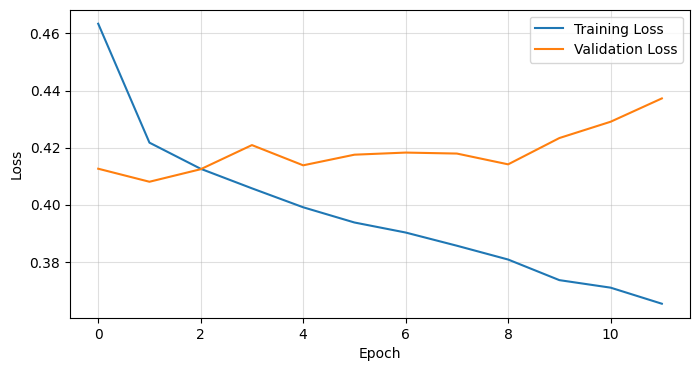

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.grid(alpha=0.4)

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Loss")

Text(0, 0.5, 'Accuracy')

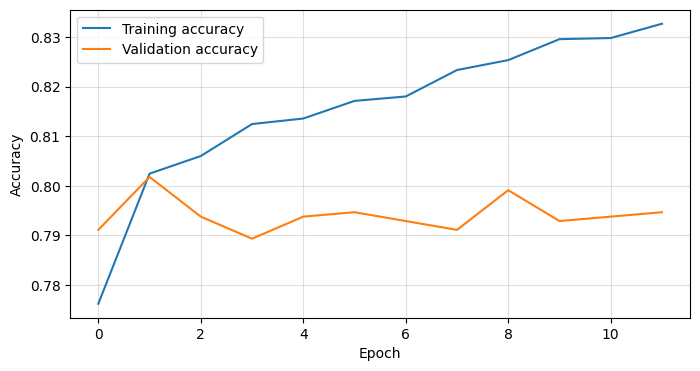

In [36]:
plt.figure(figsize=(8,4))

plt.plot(history.history['accuracy'], label='Training accuracy')

plt.plot(history.history['val_accuracy'], label='Validation accuracy')

plt.grid(alpha=0.4)

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

In [37]:
loss, accuracy = ann_model.evaluate(
    X_test_scaled,
    y_test
)

print("Loss :", loss)
print("Accuracy :", accuracy)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7818 - loss: 0.4418
Loss : 0.4417663514614105
Accuracy : 0.7818052768707275


# Predictions

In [38]:
y_prob = ann_model.predict(
    X_test_scaled
)

y_pred = (
    y_prob > 0.5
).astype(int)

print(
    classification_report(
        y_test,
        y_pred
    )
)

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.59      0.61      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.72      1407
weighted avg       0.78      0.78      0.78      1407



# Model creation using hypertuning

In [39]:
import keras_tuner as kt

In [40]:
def build_model(hp):
    
    model = models.Sequential()

    model.add(
    layers.Input(shape=(X_train_scaled.shape[1],))
    )    
    
    n_layers = hp.Int('n_layers',min_value=1,max_value=4, step=1)
    
    for i in range(n_layers):
        model.add(layers.Dense(units = hp.Int(f"units_{i}", min_value=16, max_value=256, step=16), 
                               activation = hp.Choice(f"activation_{i}", values=['relu','tanh','elu']), 
                               kernel_regularizer = tf.keras.regularizers.l2(hp.Float(f"lr_{i}", min_value=1e-5, 
                                                    max_value=1e-2, sampling='log')))) 
        
        model.add(layers.Dropout(rate = hp.Float(f"dropout_{i}", min_value=0.0, max_value=0.5, step=0.1)))
    model.add(layers.Dense(1, activation='sigmoid'))
    
    #learning rate and oiptimser
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log') 
    optimizer = hp.Choice('optimizer',values=['adam','rmsprop','sgd'])
    
    if optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate) 
    elif optimizer == "rmsprop":
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate) 
    else:
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate,momentum=0.9)
    
    model.compile(optimizer=opt, loss='binary_crossentropy',metrics=['accuracy']) 
    
    return model

In [41]:
tuner = kt.BayesianOptimization(hypermodel = build_model, 
                                objective='val_accuracy', 
                                max_trials = 20, 
                                num_initial_points=5, 
                                #random 
                                seed = 10, 
                                directory = 'keras_tuner_logs', 
                                project_name = "misson_ai_sekho" 
                               )

In [42]:
tuner.search_space_summary()

Search space summary
Default search space size: 7
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 256, 'step': 16, 'sampling': 'linear'}
activation_0 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'elu'], 'ordered': False}
lr_0 (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
dropout_0 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'sgd'], 'ordered': False}


In [43]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5)

In [44]:
tuner.search(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split = 0.20,
    callbacks=[stop_early]
)

Trial 20 Complete [00h 00m 26s]
val_accuracy: 0.8151111006736755

Best val_accuracy So Far: 0.8159999847412109
Total elapsed time: 00h 07m 06s


In [45]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

In [46]:
for i in range(best_hps.get('n_layers')): 
    print(f" Layer {i+1} units : {best_hps.get(f'units_{i}')}") 
    print(f" Layer {i+1} activation : {best_hps.get(f'activation_{i}')}") 
    print(f" Layer {i+1} dropout : {best_hps.get(f'dropout_{i}')}") 
    print(f" Layer {i+1} L2 : {best_hps.get(f'lr_{i}')}") 
print(f" Optimizer : {best_hps.get(f'optimizer')}") 
print(f" Learning Rate : {best_hps.get(f'learning_rate')}")

 Layer 1 units : 160
 Layer 1 activation : elu
 Layer 1 dropout : 0.0
 Layer 1 L2 : 0.0016395963430189458
 Layer 2 units : 192
 Layer 2 activation : elu
 Layer 2 dropout : 0.4
 Layer 2 L2 : 6.531909530446208e-05
 Layer 3 units : 128
 Layer 3 activation : tanh
 Layer 3 dropout : 0.1
 Layer 3 L2 : 0.0007656632202775268
 Optimizer : sgd
 Learning Rate : 0.0009393967449438109


In [47]:
best_model = tuner.hypermodel.build(best_hps)

history = best_model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=32,
    validation_split = 0.20,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)],
)

Epoch 1/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7389 - loss: 0.7262 - val_accuracy: 0.7920 - val_loss: 0.6361
Epoch 2/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7838 - loss: 0.6578 - val_accuracy: 0.7929 - val_loss: 0.6200
Epoch 3/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7876 - loss: 0.6466 - val_accuracy: 0.8009 - val_loss: 0.6129
Epoch 4/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7947 - loss: 0.6398 - val_accuracy: 0.8009 - val_loss: 0.6115
Epoch 5/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7938 - loss: 0.6352 - val_accuracy: 0.7964 - val_loss: 0.6090
Epoch 6/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7913 - loss: 0.6365 - val_accuracy: 0.8036 - val_loss: 0.6059
Epoch 7/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7978 - loss: 0.6318 - val_accuracy: 0.8053 - val_loss: 0.6028
Epoch 8/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7971 - loss: 0.6317 - val_acc

In [48]:
loss, accuracy = best_model.evaluate(X_test_scaled, y_test) 
print(f"loss : {loss}") 
print(f"accuracy : {accuracy}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7989 - loss: 0.5070
loss : 0.5070332288742065
accuracy : 0.7988628149032593


Text(0, 0.5, 'Loss (bayesian)')

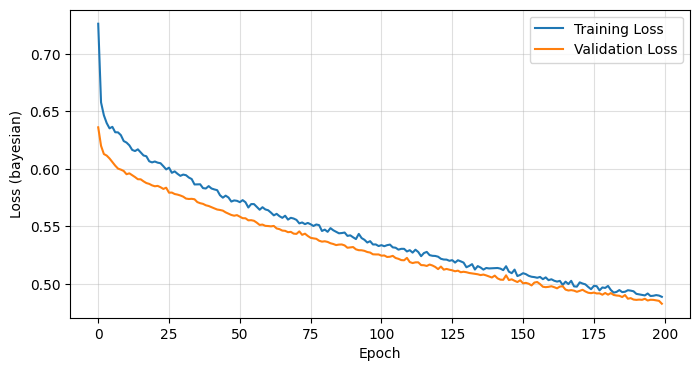

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4)) 
plt.plot(history.history['loss'], label='Training Loss') 
plt.plot(history.history['val_loss'], label='Validation Loss') 
plt.grid(alpha=0.4) 
plt.legend() 
plt.xlabel("Epoch") 
plt.ylabel("Loss (bayesian)")

Text(0, 0.5, 'Loss (bayesian)')

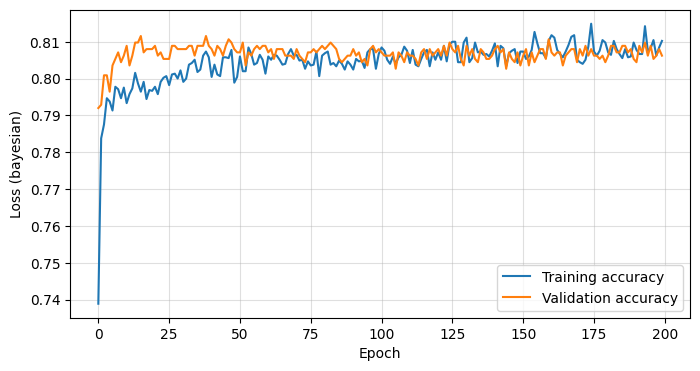

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4)) 
plt.plot(history.history['accuracy'], label='Training accuracy') 
plt.plot(history.history['val_accuracy'], label='Validation accuracy') 
plt.grid(alpha=0.4) 
plt.legend() 
plt.xlabel("Epoch") 
plt.ylabel("Loss (bayesian)")

In [51]:
file_path = "/kaggle/working/best_churn_model.keras"

if os.path.exists(file_path):
    os.remove(file_path)

best_model.save("best_churn_model.keras")

In [52]:
with open('selected_feature.pkl','wb') as f: 
    pickle.dump(selected_features,f)

In [53]:
def load_model_comp(): 
    model = tf.keras.models.load_model('/kaggle/working/best_churn_model.keras')

    #load scaler 
    with open('scaler.pkl','rb') as f: 
        scaler = pickle.load(f)

    with open('selected_features.pkl','rb') as f: 
        selected_features = pickle.load(f)

    return model, scaler, selected_features

In [54]:
X[selected_features].head(3)

,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,29.85,29.85,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0
1,1,0,34,56.95,1889.50,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1
2,1,0,2,53.85,108.15,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,1


In [55]:
X[selected_features].shape

(7032, 27)

In [56]:
sample_customer = pd.DataFrame([[
    1,      # gender
    0,      # SeniorCitizen
    48,     # tenure
    45.50,  # MonthlyCharges
    2200,   # TotalCharges

    1,      # Partner_Yes
    0,      # Dependents_Yes

    1,      # PhoneService_Yes
    0,      # MultipleLines_Yes

    0,      # InternetService_Fiber optic
    0,      # InternetService_No

    0,      # OnlineSecurity_No internet service
    1,      # OnlineSecurity_Yes

    1,      # OnlineBackup_Yes

    0,      # DeviceProtection_No internet service
    1,      # DeviceProtection_Yes

    0,      # TechSupport_No internet service
    1,      # TechSupport_Yes

    1,      # StreamingTV_Yes

    0,      # StreamingMovies_No internet service
    1,      # StreamingMovies_Yes

    0,      # Contract_One year
    1,      # Contract_Two year

    0,      # PaperlessBilling_Yes

    1,      # PaymentMethod_Credit card (automatic)
    0,      # PaymentMethod_Electronic check
    0       # PaymentMethod_Mailed check

]], columns=selected_features)

In [57]:
def pred(sample_customer): 
    model,scaler, selected_feature = load_model_comp()

    sample_customer = sample_customer
    sample_scaled = scaler.transform(sample_customer) 
    prediction = model.predict(sample_scaled)[0][0] 
    print(f"Churn prob:{prediction}") 
    print(f"Will churn :{'yes' if prediction> 0.5 else 'no'}")

In [58]:
pred(sample_customer)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
Churn prob:0.02169623412191868
Will churn :no


In [59]:
sample_customer2 = X[selected_features].iloc[[0]]
sample_customer2

,gender,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,29.85,29.85,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0


In [60]:
pred(sample_customer2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
Churn prob:0.57309889793396
Will churn :yes


In [61]:
sample_customer3 = X[selected_features].iloc[[2]]
pred(sample_customer3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
Churn prob:0.2780759334564209
Will churn :no


In [62]:
sample_customer4 = X[selected_features].iloc[[3]]
pred(sample_customer4)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
Churn prob:0.03798191621899605
Will churn :no


In [63]:
sample_customer5 = X[selected_features].iloc[[4]]
pred(sample_customer5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
Churn prob:0.7246025204658508
Will churn :yes
